In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

## Imports & Folders

In [2]:
import os, numpy as np
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd

from src.ks import run_sim
from src.ic_utils import make_ic
from src.io_utils import save_h5, make_tag
from src.analysis_utils import analyze_to_pngs

RAW_DIR = "../data/raw"
FIGS_DIR = "../figs"
RESULTS_DIR = "../results"
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(FIGS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)


## single-run knobs

In [3]:
# ===== single-run config =====
L = 100.0
N = 200
dt = 0.10
steps = 20_000
save_stride = 10

ic_kind = "sin16"
noise_std = 0.00
seed = 1

print(f"Single run config: L={L}, N={N}, dt={dt}, steps={steps}, stride={save_stride}, IC={ic_kind}, noise={noise_std}")


Single run config: L=100.0, N=200, dt=0.1, steps=20000, stride=10, IC=sin16, noise=0.0


## run ONE simulation, save HDF5, make plots

In [4]:
# Build initial condition on the correct grid
x_grid = jnp.linspace(0.0, L, N, endpoint=False)
u0 = make_ic(x_grid, kind=ic_kind, noise_std=noise_std, seed=seed)

# Run simulator (your run_sim has save_stride now)
trj, x, t = run_sim(L=L, N=N, dt=dt, steps=steps, u0=u0, save_stride=save_stride)

# Tag files and save
tag = make_tag(L, N, dt, ic_kind, noise_std, seed, stride=save_stride)
out_h5 = f"{RAW_DIR}/{tag}.h5"
attrs = {"L": L, "N": N, "dt": dt, "steps": steps, "save_stride": save_stride,
         "ic_kind": ic_kind, "noise_std": noise_std, "seed": seed}
save_h5(out_h5, trj, x, t, attrs=attrs)
print("Saved:", out_h5)

# Quick analysis PNGs + summary metrics
metrics = analyze_to_pngs(np.asarray(trj), np.asarray(x), np.asarray(t), tag, figs_dir=FIGS_DIR)
metrics


Saved: ../data/raw/L100_N200_dt0.100_s10_sin16_noise0.000_seed1.h5


{'energy_mean': 1.7208642959594727,
 'change_mean': 0.2564915716648102,
 'spacetime_png': '../figs/L100_N200_dt0.100_s10_sin16_noise0.000_seed1_spacetime.png',
 'energy_png': '../figs/L100_N200_dt0.100_s10_sin16_noise0.000_seed1_energy.png',
 'change_png': '../figs/L100_N200_dt0.100_s10_sin16_noise0.000_seed1_change.png',
 'spectrum_png': '../figs/L100_N200_dt0.100_s10_sin16_noise0.000_seed1_spectrum.png'}

## Phase-1 batch (10 runs)

In [5]:
def mk_case(L=100.0, N=200, dt=0.1, steps=20_000, save_stride=10,
            ic_kind="sin16", noise_std=0.0, seed=1, group="baseline"):
    return dict(L=L, N=N, dt=dt, steps=steps, save_stride=save_stride,
                ic_kind=ic_kind, noise_std=noise_std, seed=seed, group=group)

cases = []

# 1) Noise sweep
for nz in [0.00, 0.05, 0.10]:
    cases.append(mk_case(noise_std=nz, group="noise"))

# 2) dt sweep
for d in [0.05, 0.10, 0.20]:
    cases.append(mk_case(dt=d, group="dt"))

# 3) N sweep
for N_ in [128, 512]:
    cases.append(mk_case(N=N_, group="N"))

# 4) L sweep (keep dx ≈ 0.5 -> N = 2*L)
for L_ in [50.0, 150.0]:
    cases.append(mk_case(L=L_, N=int(2*L_), group="L"))

len(cases), cases[:3]


(10,
 [{'L': 100.0,
   'N': 200,
   'dt': 0.1,
   'steps': 20000,
   'save_stride': 10,
   'ic_kind': 'sin16',
   'noise_std': 0.0,
   'seed': 1,
   'group': 'noise'},
  {'L': 100.0,
   'N': 200,
   'dt': 0.1,
   'steps': 20000,
   'save_stride': 10,
   'ic_kind': 'sin16',
   'noise_std': 0.05,
   'seed': 1,
   'group': 'noise'},
  {'L': 100.0,
   'N': 200,
   'dt': 0.1,
   'steps': 20000,
   'save_stride': 10,
   'ic_kind': 'sin16',
   'noise_std': 0.1,
   'seed': 1,
   'group': 'noise'}])

## batch runner (simulate → save → analyze all)

In [6]:
rows = []
for i, c in enumerate(cases, 1):
    # IC on correct grid
    x_tmp = jnp.linspace(0.0, c["L"], c["N"], endpoint=False)
    u0 = make_ic(x_tmp, kind=c["ic_kind"], noise_std=c["noise_std"], seed=c["seed"])

    # simulate
    trj, x, t = run_sim(L=c["L"], N=c["N"], dt=c["dt"], steps=c["steps"],
                        u0=u0, save_stride=c["save_stride"])

    # tag, save, analyze
    tag = make_tag(c["L"], c["N"], c["dt"], c["ic_kind"], c["noise_std"], c["seed"],
                   stride=c["save_stride"])
    out_h5 = f"{RAW_DIR}/{tag}.h5"
    save_h5(out_h5, trj, x, t, attrs={**c})

    metrics = analyze_to_pngs(np.asarray(trj), np.asarray(x), np.asarray(t), tag, figs_dir=FIGS_DIR)

    row = {**c, **metrics, "tag": tag, "h5": out_h5}
    rows.append(row)
    print(f"[{i}/{len(cases)}] saved {tag}")

df = pd.DataFrame(rows).sort_values(["group","tag"]).reset_index(drop=True)
df


[1/10] saved L100_N200_dt0.100_s10_sin16_noise0.000_seed1
[2/10] saved L100_N200_dt0.100_s10_sin16_noise0.050_seed1
[3/10] saved L100_N200_dt0.100_s10_sin16_noise0.100_seed1
[4/10] saved L100_N200_dt0.050_s10_sin16_noise0.000_seed1
[5/10] saved L100_N200_dt0.100_s10_sin16_noise0.000_seed1
[6/10] saved L100_N200_dt0.200_s10_sin16_noise0.000_seed1
[7/10] saved L100_N128_dt0.100_s10_sin16_noise0.000_seed1
[8/10] saved L100_N512_dt0.100_s10_sin16_noise0.000_seed1
[9/10] saved L50_N100_dt0.100_s10_sin16_noise0.000_seed1
[10/10] saved L150_N300_dt0.100_s10_sin16_noise0.000_seed1


,L,N,dt,steps,save_stride,ic_kind,noise_std,seed,group,energy_mean,change_mean,spacetime_png,energy_png,change_png,spectrum_png,tag,h5
0,150.0,300,0.10,20000,10,sin16,0.00,1,L,1.732474,0.258283,../figs/L150_N300_dt0.100_s10_sin16_noise0.000...,../figs/L150_N300_dt0.100_s10_sin16_noise0.000...,../figs/L150_N300_dt0.100_s10_sin16_noise0.000...,../figs/L150_N300_dt0.100_s10_sin16_noise0.000...,L150_N300_dt0.100_s10_sin16_noise0.000_seed1,../data/raw/L150_N300_dt0.100_s10_sin16_noise0...
1,50.0,100,0.10,20000,10,sin16,0.00,1,L,1.747736,0.238633,../figs/L50_N100_dt0.100_s10_sin16_noise0.000_...,../figs/L50_N100_dt0.100_s10_sin16_noise0.000_...,../figs/L50_N100_dt0.100_s10_sin16_noise0.000_...,../figs/L50_N100_dt0.100_s10_sin16_noise0.000_...,L50_N100_dt0.100_s10_sin16_noise0.000_seed1,../data/raw/L50_N100_dt0.100_s10_sin16_noise0....
2,100.0,128,0.10,20000,10,sin16,0.00,1,N,1.734112,0.257152,../figs/L100_N128_dt0.100_s10_sin16_noise0.000...,../figs/L100_N128_dt0.100_s10_sin16_noise0.000...,../figs/L100_N128_dt0.100_s10_sin16_noise0.000...,../figs/L100_N128_dt0.100_s10_sin16_noise0.000...,L100_N128_dt0.100_s10_sin16_noise0.000_seed1,../data/raw/L100_N128_dt0.100_s10_sin16_noise0...
3,100.0,512,0.10,20000,10,sin16,0.00,1,N,1.731116,0.259806,../figs/L100_N512_dt0.100_s10_sin16_noise0.000...,../figs/L100_N512_dt0.100_s10_sin16_noise0.000...,../figs/L100_N512_dt0.100_s10_sin16_noise0.000...,../figs/L100_N512_dt0.100_s10_sin16_noise0.000...,L100_N512_dt0.100_s10_sin16_noise0.000_seed1,../data/raw/L100_N512_dt0.100_s10_sin16_noise0...
4,100.0,200,0.05,20000,10,sin16,0.00,1,dt,1.716438,0.123198,../figs/L100_N200_dt0.050_s10_sin16_noise0.000...,../figs/L100_N200_dt0.050_s10_sin16_noise0.000...,../figs/L100_N200_dt0.050_s10_sin16_noise0.000...,../figs/L100_N200_dt0.050_s10_sin16_noise0.000...,L100_N200_dt0.050_s10_sin16_noise0.000_seed1,../data/raw/L100_N200_dt0.050_s10_sin16_noise0...
5,100.0,200,0.10,20000,10,sin16,0.00,1,dt,1.720864,0.256492,../figs/L100_N200_dt0.100_s10_sin16_noise0.000...,../figs/L100_N200_dt0.100_s10_sin16_noise0.000...,../figs/L100_N200_dt0.100_s10_sin16_noise0.000...,../figs/L100_N200_dt0.100_s10_sin16_noise0.000...,L100_N200_dt0.100_s10_sin16_noise0.000_seed1,../data/raw/L100_N200_dt0.100_s10_sin16_noise0...
6,100.0,200,0.20,20000,10,sin16,0.00,1,dt,1.768596,0.534454,../figs/L100_N200_dt0.200_s10_sin16_noise0.000...,../figs/L100_N200_dt0.200_s10_sin16_noise0.000...,../figs/L100_N200_dt0.200_s10_sin16_noise0.000...,../figs/L100_N200_dt0.200_s10_sin16_noise0.000...,L100_N200_dt0.200_s10_sin16_noise0.000_seed1,../data/raw/L100_N200_dt0.200_s10_sin16_noise0...
7,100.0,200,0.10,20000,10,sin16,0.00,1,noise,1.720864,0.256492,../figs/L100_N200_dt0.100_s10_sin16_noise0.000...,../figs/L100_N200_dt0.100_s10_sin16_noise0.000...,../figs/L100_N200_dt0.100_s10_sin16_noise0.000...,../figs/L100_N200_dt0.100_s10_sin16_noise0.000...,L100_N200_dt0.100_s10_sin16_noise0.000_seed1,../data/raw/L100_N200_dt0.100_s10_sin16_noise0...
8,100.0,200,0.10,20000,10,sin16,0.05,1,noise,1.721224,0.256135,../figs/L100_N200_dt0.100_s10_sin16_noise0.050...,../figs/L100_N200_dt0.100_s10_sin16_noise0.050...,../figs/L100_N200_dt0.100_s10_sin16_noise0.050...,../figs/L100_N200_dt0.100_s10_sin16_noise0.050...,L100_N200_dt0.100_s10_sin16_noise0.050_seed1,../data/raw/L100_N200_dt0.100_s10_sin16_noise0...
9,100.0,200,0.10,20000,10,sin16,0.10,1,noise,1.749958,0.259855,../figs/L100_N200_dt0.100_s10_sin16_noise0.100...,../figs/L100_N200_dt0.100_s10_sin16_noise0.100...,../figs/L100_N200_dt0.100_s10_sin16_noise0.100...,../figs/L100_N200_dt0.100_s10_sin16_noise0.100...,L100_N200_dt0.100_s10_sin16_noise0.100_seed1,../data/raw/L100_N200_dt0.100_s10_sin16_noise0...


## comparison plots (noise, dt, N, L)

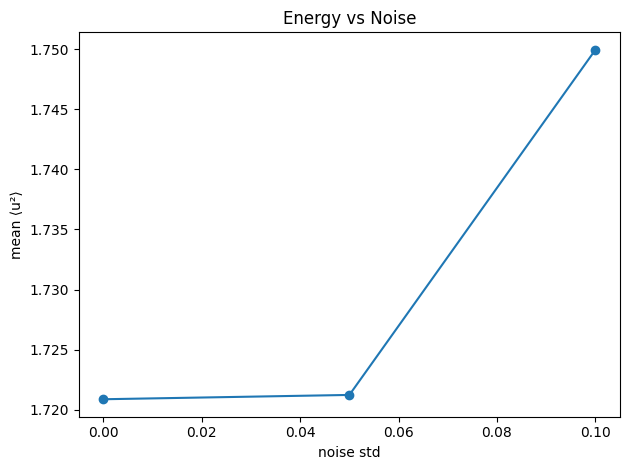

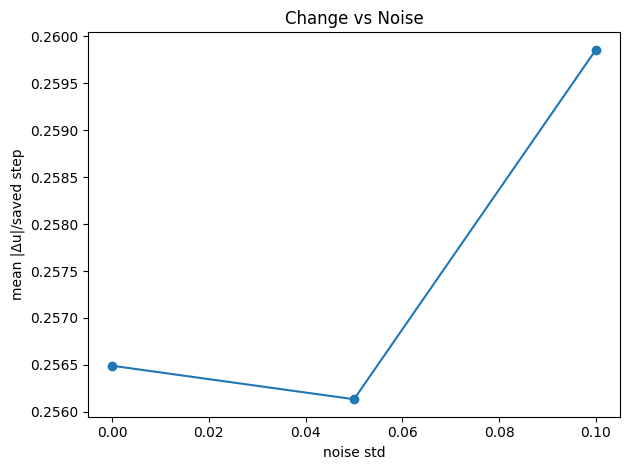

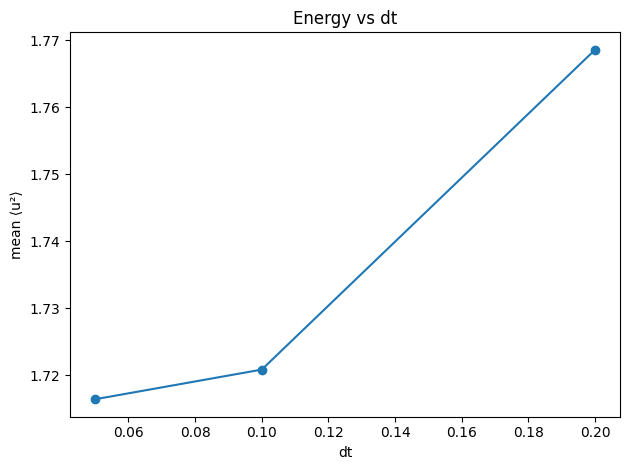

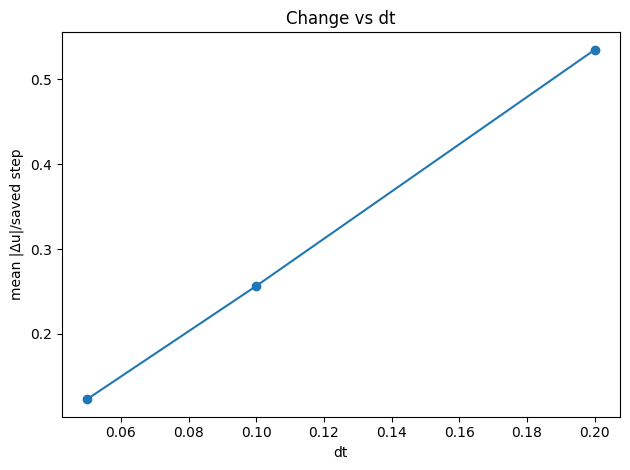

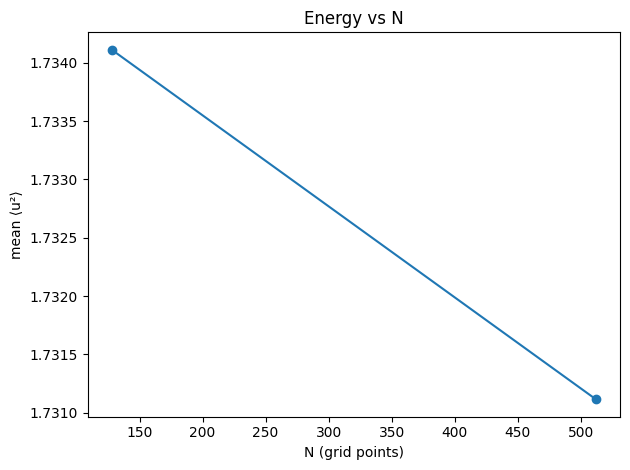

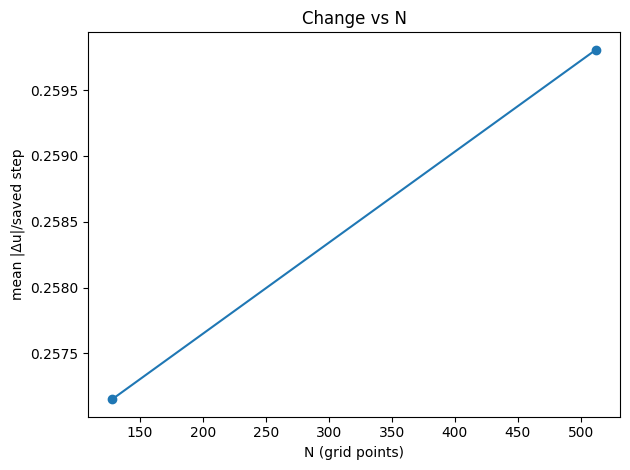

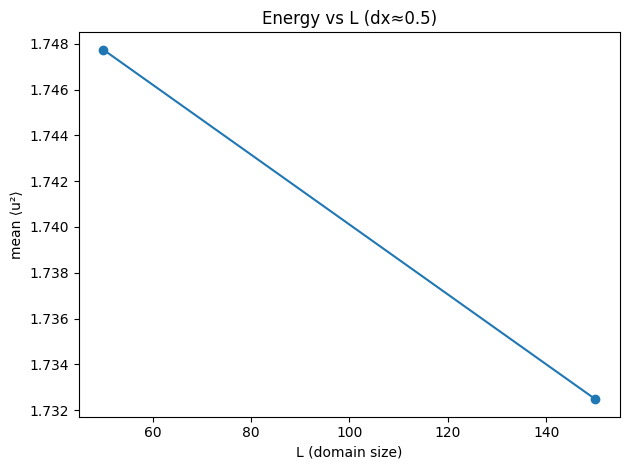

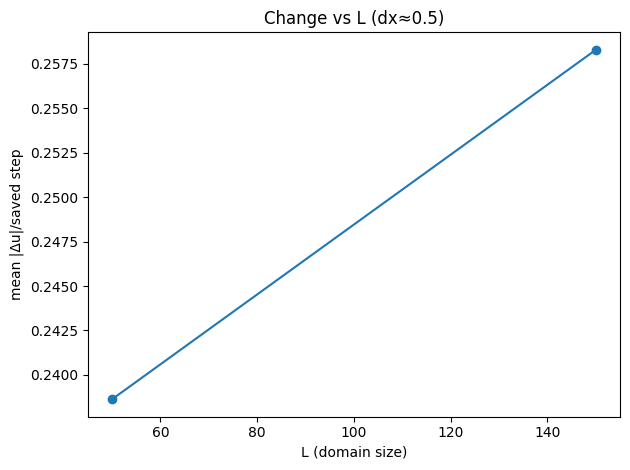

In [7]:
import matplotlib.pyplot as plt

def lineplot(x, y, xlab, ylab, title):
    plt.figure()
    plt.plot(x, y, marker="o")
    plt.xlabel(xlab); plt.ylabel(ylab); plt.title(title)
    plt.tight_layout(); plt.show()

# Noise
d_noise = df[df.group=="noise"].sort_values("noise_std")
lineplot(d_noise.noise_std, d_noise.energy_mean, "noise std", "mean ⟨u²⟩", "Energy vs Noise")
lineplot(d_noise.noise_std, d_noise.change_mean, "noise std", "mean |Δu|/saved step", "Change vs Noise")

# dt
d_dt = df[df.group=="dt"].sort_values("dt")
lineplot(d_dt.dt, d_dt.energy_mean, "dt", "mean ⟨u²⟩", "Energy vs dt")
lineplot(d_dt.dt, d_dt.change_mean, "dt", "mean |Δu|/saved step", "Change vs dt")

# N
d_N = df[df.group=="N"].sort_values("N")
lineplot(d_N.N, d_N.energy_mean, "N (grid points)", "mean ⟨u²⟩", "Energy vs N")
lineplot(d_N.N, d_N.change_mean, "N (grid points)", "mean |Δu|/saved step", "Change vs N")

# L (dx≈0.5)
d_L = df[df.group=="L"].sort_values("L")
lineplot(d_L.L, d_L.energy_mean, "L (domain size)", "mean ⟨u²⟩", "Energy vs L (dx≈0.5)")
lineplot(d_L.L, d_L.change_mean, "L (domain size)", "mean |Δu|/saved step", "Change vs L (dx≈0.5)")


## “gallery” of space-time images per group

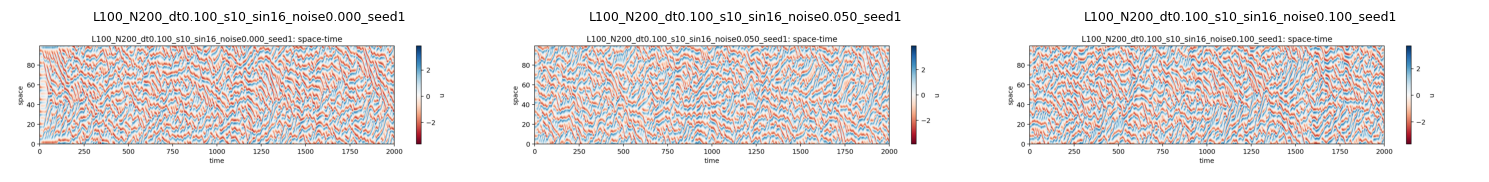

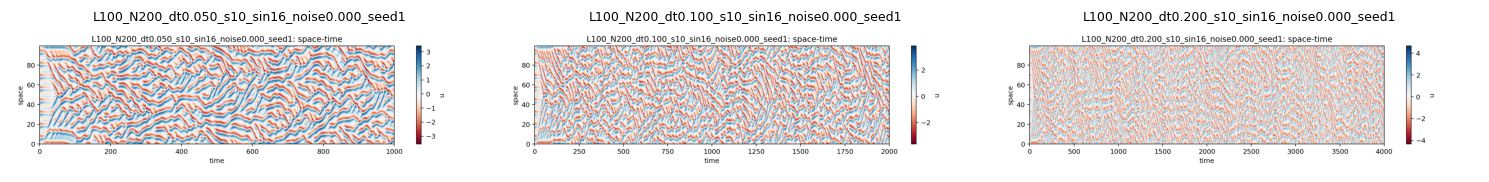

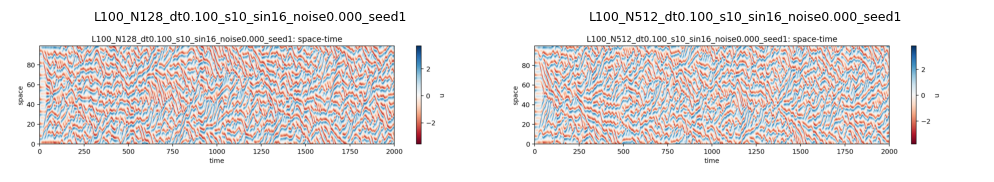

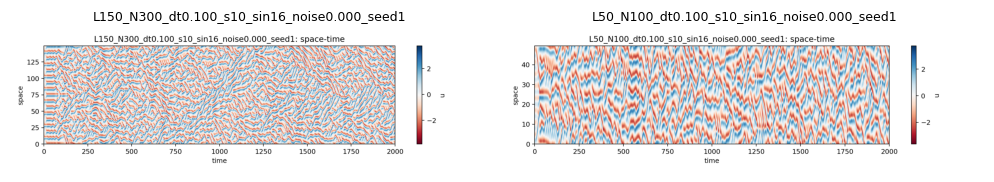

In [8]:
import math, matplotlib.image as mpimg

def gallery(group, cols=3):
    d = df[df.group==group]
    n = len(d); rows = math.ceil(n/cols) if n else 1
    plt.figure(figsize=(5*cols, 2.8*rows))
    for i, (_, r) in enumerate(d.iterrows(), 1):
        plt.subplot(rows, cols, i)
        img = mpimg.imread(r["spacetime_png"])
        plt.imshow(img)
        plt.axis("off")
        plt.title(r["tag"], fontsize=9)
    plt.tight_layout(); plt.show()

gallery("noise")
gallery("dt")
gallery("N")
gallery("L")


## save summary CSV

In [9]:
df_out = df[["group","tag","L","N","dt","steps","save_stride","ic_kind","noise_std",
             "energy_mean","change_mean","h5","spacetime_png","energy_png","change_png","spectrum_png"]]
csv_path = f"{RESULTS_DIR}/phase1_summary.csv"
df_out.to_csv(csv_path, index=False)
csv_path, df_out.head()


('../results/phase1_summary.csv',
   group                                           tag      L    N    dt  \
 0     L  L150_N300_dt0.100_s10_sin16_noise0.000_seed1  150.0  300  0.10   
 1     L   L50_N100_dt0.100_s10_sin16_noise0.000_seed1   50.0  100  0.10   
 2     N  L100_N128_dt0.100_s10_sin16_noise0.000_seed1  100.0  128  0.10   
 3     N  L100_N512_dt0.100_s10_sin16_noise0.000_seed1  100.0  512  0.10   
 4    dt  L100_N200_dt0.050_s10_sin16_noise0.000_seed1  100.0  200  0.05   
 
    steps  save_stride ic_kind  noise_std  energy_mean  change_mean  \
 0  20000           10   sin16        0.0     1.732474     0.258283   
 1  20000           10   sin16        0.0     1.747736     0.238633   
 2  20000           10   sin16        0.0     1.734112     0.257152   
 3  20000           10   sin16        0.0     1.731116     0.259806   
 4  20000           10   sin16        0.0     1.716438     0.123198   
 
                                                   h5  \
 0  ../data/raw/L150_N3

In [12]:
import pandas as pd, numpy as np, os

CSV = "../results/phase1_summary.csv"
assert os.path.exists(CSV), f"Missing: {CSV}"
df = pd.read_csv(CSV)

# If group/others are missing (older CSV), make safe fallbacks
if "group" not in df.columns: df["group"] = "unknown"
for col in ["steps","save_stride","ic_kind","seed","L","N","dt","noise_std"]:
    if col not in df.columns:
        # create placeholder if truly missing
        df[col] = np.nan

print("=== COLUMNS IN CSV ===")
print(sorted(df.columns.tolist()))

print("\n=== UNIQUE SETTINGS USED (only columns that exist) ===")
for k in ["steps","save_stride","ic_kind","seed","L","N","dt","noise_std","group"]:
    if k in df.columns:
        vals = df[k].dropna().unique().tolist()
        print(f"{k}: {sorted(vals)}")

print("\n=== COUNTS PER GROUP ===")
print(df["group"].value_counts())

print("\n=== HEAD ===")
print(df.head(3).to_string(index=False))
print("\n=== TAIL ===")
print(df.tail(3).to_string(index=False))


=== COLUMNS IN CSV ===
['L', 'N', 'change_mean', 'change_png', 'dt', 'energy_mean', 'energy_png', 'group', 'h5', 'ic_kind', 'noise_std', 'save_stride', 'seed', 'spacetime_png', 'spectrum_png', 'steps', 'tag']

=== UNIQUE SETTINGS USED (only columns that exist) ===
steps: [20000]
save_stride: [10]
ic_kind: ['sin16']
seed: []
L: [50.0, 100.0, 150.0]
N: [100, 128, 200, 300, 512]
dt: [0.05, 0.1, 0.2]
noise_std: [0.0, 0.05, 0.1]
group: ['L', 'N', 'dt', 'noise']

=== COUNTS PER GROUP ===
group
noise    3
dt       3
N        2
L        2
Name: count, dtype: int64

=== HEAD ===
group                                          tag     L   N  dt  steps  save_stride ic_kind  noise_std  energy_mean  change_mean                                                          h5                                                      spacetime_png                                                      energy_png                                                      change_png                                       

In [13]:
## Quantify trends
import numpy as np

def summarize_group(dfin, key):
    d = dfin.dropna(subset=[key, "energy_mean", "change_mean"]).sort_values(key)
    x = d[key].to_numpy(float)
    e = d["energy_mean"].to_numpy(float)
    c = d["change_mean"].to_numpy(float)
    if len(x) < 2:
        return {"note": f"not enough points for {key} (need ≥2)"}
    pe = np.polyfit(x, e, 1); pc = np.polyfit(x, c, 1)
    def r2(y, yhat): 
        ss_res = ((y - yhat)**2).sum(); ss_tot = ((y - y.mean())**2).sum()
        return 0.0 if ss_tot==0 else 1 - ss_res/ss_tot
    e_hat = np.polyval(pe, x); c_hat = np.polyval(pc, x)
    return {
        "x": x.tolist(),
        "energy": e.tolist(),
        "change": c.tolist(),
        "energy_slope": float(pe[0]),
        "change_slope": float(pc[0]),
        "energy_r2": float(r2(e, e_hat)),
        "change_r2": float(r2(c, c_hat)),
        "energy_pct_span": float(100*(e.max()-e.min())/max(1e-12, e.mean())),
        "change_pct_span": float(100*(c.max()-c.min())/max(1e-12, c.mean())),
    }

print("=== TRENDS ===")
groups = {"noise":"noise_std", "dt":"dt", "N":"N", "L":"L"}
for g, key in groups.items():
    if (df["group"]==g).any() and key in df.columns:
        res = summarize_group(df[df["group"]==g], key)
        print(f"\n[{g}] by {key}")
        for k,v in res.items():
            print(f"  {k}: {v}")
    else:
        print(f"\n[{g}] missing group or key column ({key}) — skipping")


=== TRENDS ===

[noise] by noise_std
  x: [0.0, 0.05, 0.1]
  energy: [1.7208642959594729, 1.7212238311767578, 1.7499582767486572]
  change: [0.2564915716648102, 0.2561350166797638, 0.259855180978775]
  energy_slope: 0.29093980789184726
  change_slope: 0.03363609313964843
  energy_r2: 0.7592668558071612
  change_r2: 0.6712968442999436
  energy_pct_span: 1.6810701518816427
  change_pct_span: 1.4447580953023216

[dt] by dt
  x: [0.05, 0.1, 0.2]
  energy: [1.7164376974105835, 1.7208642959594729, 1.7685964107513428]
  change: [0.1231975108385086, 0.2564915716648102, 0.5344542860984802]
  energy_slope: 0.3662385259355844
  change_slope: 2.747128307819367
  energy_r2: 0.9354569813013611
  change_r2: 0.9998950473475813
  energy_pct_span: 3.005747094457299
  change_pct_span: 134.96464210717755

[N] by N
  x: [128.0, 512.0]
  energy: [1.7341116666793823, 1.7311162948608398]
  change: [0.2571519911289215, 0.2598056495189667]
  energy_slope: -7.800447444121513e-06
  change_slope: 6.910568724075756

In [15]:
##Peak amplitude per run
import h5py, numpy as np

def u_absmax(h5_path):
    with h5py.File(h5_path, "r") as f:
        u = f["u"][:]
    return float(np.abs(u).max())

if "u_absmax" not in df.columns:
    df["u_absmax"] = df["h5"].apply(u_absmax)

cols = [c for c in ["group","tag","L","N","dt","noise_std","energy_mean","change_mean","u_absmax","h5"] if c in df.columns]
print(df[cols].sort_values(["group","tag"]).to_string(index=False))

# Save updated CSV
out_csv = "../results/phase1_summary_with_uabsmax.csv"
df.to_csv(out_csv, index=False)
print("\nSaved", out_csv)


group                                          tag     L   N   dt  noise_std  energy_mean  change_mean  u_absmax                                                          h5
    L L150_N300_dt0.100_s10_sin16_noise0.000_seed1 150.0 300 0.10       0.00     1.732474     0.258283  3.832421 ../data/raw/L150_N300_dt0.100_s10_sin16_noise0.000_seed1.h5
    L  L50_N100_dt0.100_s10_sin16_noise0.000_seed1  50.0 100 0.10       0.00     1.747736     0.238633  3.740102  ../data/raw/L50_N100_dt0.100_s10_sin16_noise0.000_seed1.h5
    N L100_N128_dt0.100_s10_sin16_noise0.000_seed1 100.0 128 0.10       0.00     1.734112     0.257152  3.698873 ../data/raw/L100_N128_dt0.100_s10_sin16_noise0.000_seed1.h5
    N L100_N512_dt0.100_s10_sin16_noise0.000_seed1 100.0 512 0.10       0.00     1.731116     0.259806  3.811795 ../data/raw/L100_N512_dt0.100_s10_sin16_noise0.000_seed1.h5
   dt L100_N200_dt0.050_s10_sin16_noise0.000_seed1 100.0 200 0.05       0.00     1.716438     0.123198  3.558640 ../data/raw/L100_N200_

In [18]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os

CSV = "../results/phase1_summary_with_uabsmax.csv"
FIGS = "../figs"
os.makedirs(FIGS, exist_ok=True)
df = pd.read_csv(CSV)

def save_line(dfsub, xcol, ycol, out, xlab, ylab, title):
    d = dfsub.sort_values(xcol)
    plt.figure()
    plt.plot(d[xcol], d[ycol], marker="o")
    plt.xlabel(xlab); plt.ylabel(ylab); plt.title(title)
    plt.tight_layout(); plt.savefig(os.path.join(FIGS, out), dpi=180); plt.close()

# dt trends
save_line(df[df.group=="dt"], "dt", "energy_mean", "summary_energy_vs_dt.png", "dt", "mean ⟨u²⟩", "Energy vs dt")
save_line(df[df.group=="dt"], "dt", "change_mean", "summary_change_vs_dt.png", "dt", "mean |Δu|/saved step", "Change vs dt")

# noise trends
save_line(df[df.group=="noise"], "noise_std", "energy_mean", "summary_energy_vs_noise.png", "noise std", "mean ⟨u²⟩", "Energy vs noise")
save_line(df[df.group=="noise"], "noise_std", "change_mean", "summary_change_vs_noise.png", "noise std", "mean |Δu|/saved step", "Change vs noise")
